# NLP Disaster Tweets — EDA & Model

This notebook covers the full pipeline for the **NLP Getting Started** Kaggle competition:
classifying tweets as real disaster reports or not.

The notebook is divided into three main sections:
1. **Setup** — loading libraries and data
2. **Exploratory Data Analysis (EDA)** — understanding the dataset through visualizations
3. **Modeling** — text preprocessing and training a neural network classifier


## 1. Setup

### 1.1 Import Libraries

We import all necessary libraries upfront: data manipulation (`pandas`, `numpy`), 
visualization (`matplotlib`, `seaborn`), NLP tools (`nltk`, `gensim`, `wordcloud`), 
and deep learning frameworks (`tensorflow`, `keras`, `torch`).


In [61]:
import pandas as pd
import numpy as np
import os
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Esto es para poder leer stopwords (Palabras que no transmiten ninguna idea, únicamente una pausa)
from nltk.corpus import stopwords
from nltk.util import ngrams

from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.metrics import classification_report,confusion_matrix

from collections import defaultdict
from collections import Counter
plt.style.use('seaborn-v0_8')
import nltk
# nltk.download('stopwords')
stop=set(stopwords.words('english'))

import re
from nltk.tokenize import word_tokenize
import gensim
import string

from tqdm import tqdm
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding, LSTM,Dense, SpatialDropout1D, Dropout
from keras.initializers import Constant
from keras.optimizers import Adam
import os
import torch

import warnings
warnings.simplefilter('ignore')


### 1.2 Load Data

We load the training and test CSV files. The training set contains labeled tweets 
(`target=1` for real disaster, `target=0` for not), while the test set has no labels.


In [62]:
train_tweet = os.path.join('data', 'disaster_tweets', 'train.csv')
test_tweet = os.path.join('data', 'disaster_tweets', 'test.csv')
train_tweet = pd.read_csv(train_tweet)
test_tweet = pd.read_csv(test_tweet)


In [63]:
# Print dataset dimensions to get a quick overview
print('There are {} rows and {} columns in train'.format(train_tweet.shape[0],train_tweet.shape[1]))
print('There are {} rows and {} columns in test'.format(test_tweet.shape[0],test_tweet.shape[1]))


There are 7613 rows and 5 columns in train
There are 3263 rows and 4 columns in test


In [64]:
train_tweet.head(10)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1
5,8,NaN,NaN,#RockyFire Update => California Hwy. 20 closed in both directions due to Lake County fire - #CAf...,1
6,10,NaN,NaN,"#flood #disaster Heavy rain causes flash flooding of streets in Manitou, Colorado Springs areas",1
7,13,NaN,NaN,I'm on top of the hill and I can see a fire in the woods...,1
8,14,NaN,NaN,There's an emergency evacuation happening now in the building across the street,1
9,15,NaN,NaN,I'm afraid that the tornado is coming to our area...,1


## 2. Exploratory Data Analysis (EDA)

Before building any model, it's crucial to understand the data. 
In this section we explore the class distribution, tweet lengths (in characters and words), 
average word length, and the most common words (including stopwords) per class.


### 2.1 Class Distribution

The dataset is a binary classification problem. We check whether the classes are balanced 
or if one label dominates the other, since imbalanced data can affect model performance.


In [65]:
# extracting the number of examples of each class
Real_len = train_tweet[train_tweet['target'] == 1].shape[0]
Not_len = train_tweet[train_tweet['target'] == 0].shape[0]

The bar chart below shows the number of tweets per class. 
The x-axis is just a positional axis for the bars, while the y-axis shows the count. 
Blue represents **Real disaster tweets** (target=1) and red represents **Non-disaster tweets** (target=0).
The classes are slightly imbalanced, with more non-disaster tweets than real ones.


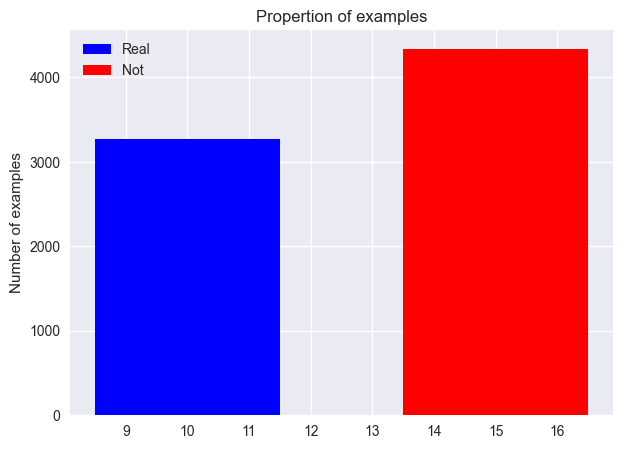

In [66]:
# bar plot of the 2 classes
plt.rcParams['figure.figsize'] = (7, 5)
plt.bar(10,Real_len,3, label="Real", color='blue')
plt.bar(15,Not_len,3, label="Not", color='red')
plt.legend()
plt.ylabel('Number of examples')
plt.title('Propertion of examples')
plt.show()


### 2.2 Tweet Length Analysis (Characters)

We now look at how long tweets are in terms of character count. 
Differences in length between the two classes could serve as a useful signal for the classifier — 
real disaster tweets might use more urgent or descriptive language, affecting their length.


In [67]:
def length(text):    
    '''a function which returns the length of text'''
    return len(text)


In [68]:
# Add a new column with the character length of each tweet
train_tweet['length'] = train_tweet['text'].apply(length)


The histogram below overlays both classes. The x-axis shows tweet length in characters 
and the y-axis shows frequency. Notice that real disaster tweets tend to be **slightly longer** 
on average — likely because they contain more descriptive detail.


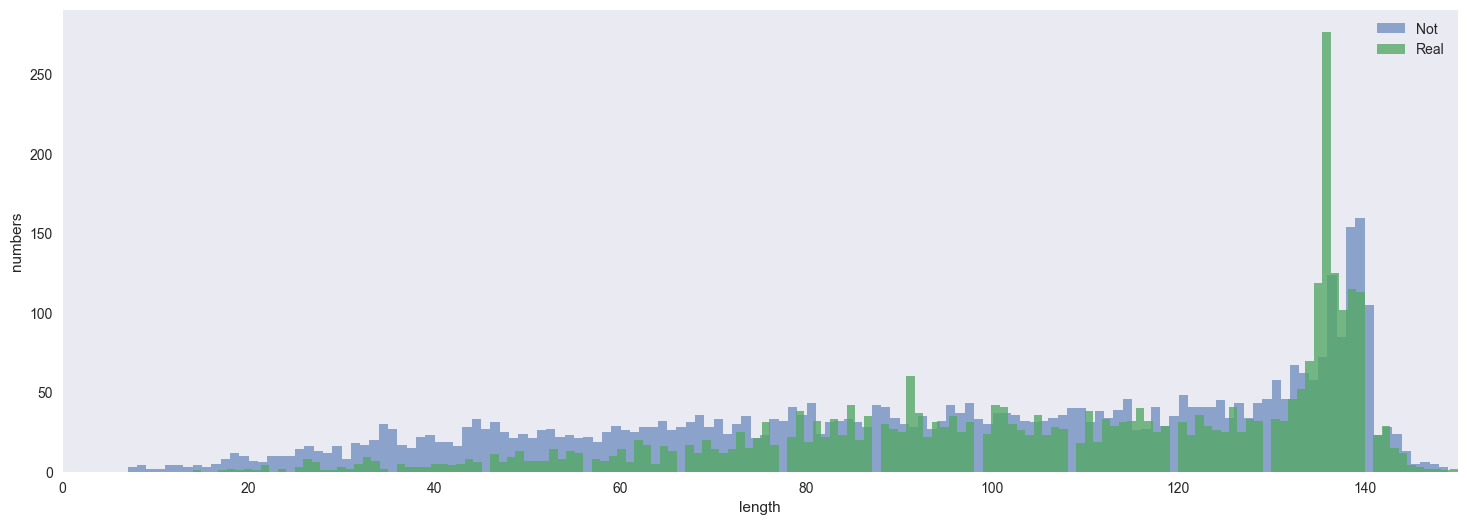

In [69]:
plt.rcParams['figure.figsize'] = (18.0, 6.0)
bins = 150
plt.hist(train_tweet[train_tweet['target'] == 0]['length'], alpha = 0.6, bins=bins, label='Not')
plt.hist(train_tweet[train_tweet['target'] == 1]['length'], alpha = 0.8, bins=bins, label='Real')
plt.xlabel('length')
plt.ylabel('numbers')
plt.legend(loc='upper right')
plt.xlim(0,150)
plt.grid()
plt.show()


The following side-by-side histograms show the same character length distribution 
but with the classes separated, making it easier to compare shapes individually.


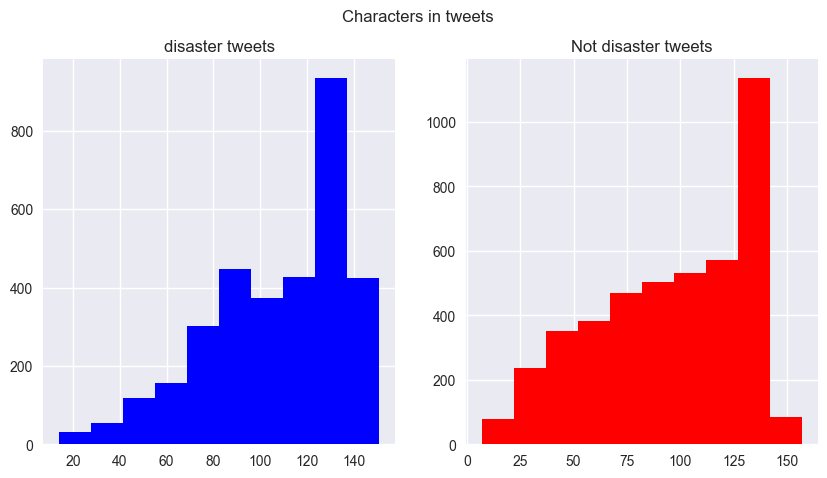

In [70]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
tweet_len=train_tweet[train_tweet['target']==1]['text'].str.len()
ax1.hist(tweet_len,color='blue')
ax1.set_title('disaster tweets')
tweet_len=train_tweet[train_tweet['target']==0]['text'].str.len()
ax2.hist(tweet_len,color='red')
ax2.set_title('Not disaster tweets')
fig.suptitle('Characters in tweets')
plt.show()


### 2.3 Word Count Distribution

Beyond character count, we analyze the number of **words** per tweet. 
This helps us understand vocabulary usage and whether disaster tweets tend to pack more words.


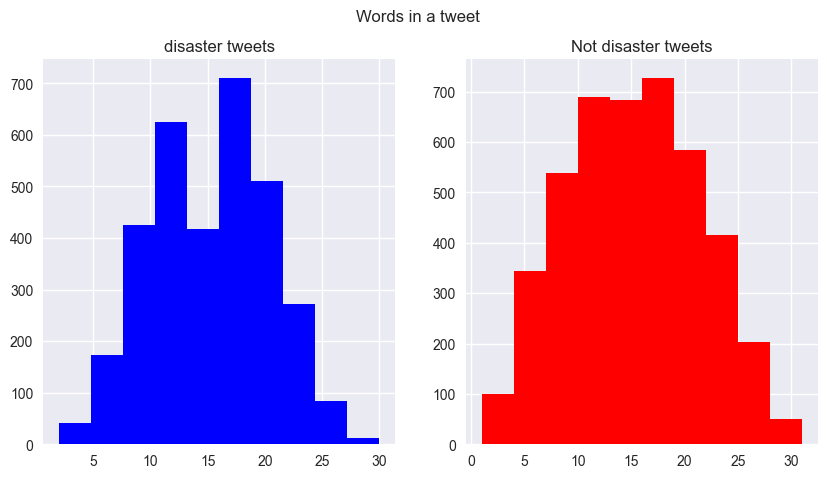

In [71]:
# Split each tweet into words and count them per class
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
tweet_len=train_tweet[train_tweet['target']==1]['text'].str.split().map(lambda x: len(x))
ax1.hist(tweet_len,color='blue')
ax1.set_title('disaster tweets')
tweet_len=train_tweet[train_tweet['target']==0]['text'].str.split().map(lambda x: len(x))
ax2.hist(tweet_len,color='red')
ax2.set_title('Not disaster tweets')
fig.suptitle('Words in a tweet')
plt.show()


### 2.4 Average Word Length Distribution

Here we compute the **average length of words** within each tweet. 
Tweets with longer average word length may contain more technical or formal vocabulary — 
a potential differentiator between real disaster reports and casual posts.


0                                  [3, 5, 3, 3, 6, 2, 4, 11, 3, 5, 7, 2, 3]
1                                                     [6, 4, 4, 2, 5, 5, 6]
2       [3, 9, 5, 2, 8, 2, 6, 3, 5, 8, 2, 9, 2, 5, 10, 2, 7, 2, 5, 6, 3, 8]
3                                               [6, 6, 7, 10, 10, 6, 2, 10]
4                         [4, 3, 4, 4, 5, 4, 4, 7, 2, 5, 4, 10, 5, 4, 1, 6]
                                       ...                                 
7608                                     [3, 5, 6, 7, 1, 6, 8, 4, 6, 5, 22]
7609       [12, 12, 3, 3, 2, 7, 4, 5, 2, 10, 4, 2, 3, 8, 4, 2, 3, 6, 4, 10]
7610                                              [5, 6, 8, 1, 2, 7, 7, 22]
7611            [6, 13, 5, 2, 6, 8, 4, 1, 3, 2, 6, 9, 6, 5, 8, 7, 8, 11, 9]
7612                              [3, 7, 4, 5, 5, 2, 8, 10, 8, 1, 3, 4, 22]
Name: text, Length: 3271, dtype: object


Text(0.5, 0.98, 'Average word length in each tweet')

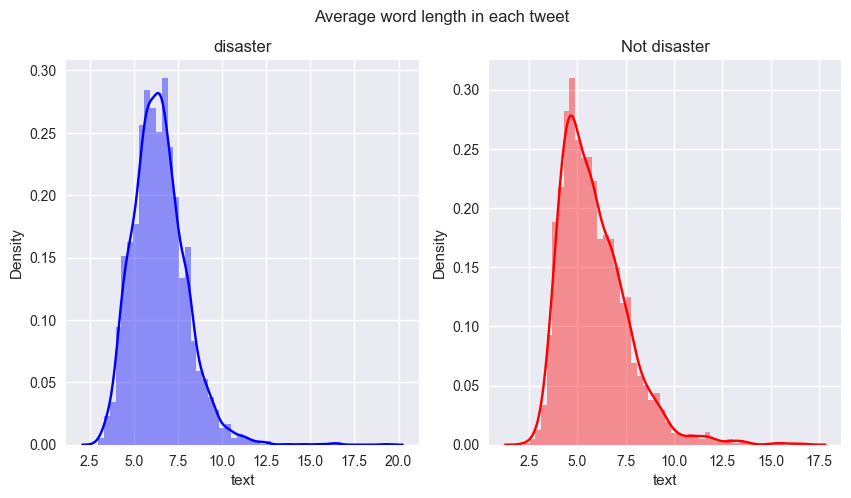

In [72]:
# Compute the mean word length for each tweet, then plot the distribution
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
word=train_tweet[train_tweet['target']==1]['text'].str.split().apply(lambda x : [len(i) for i in x])
print(word)
sns.distplot(word.map(lambda x: np.mean(x)),ax=ax1,color='blue')
ax1.set_title('disaster')
word=train_tweet[train_tweet['target']==0]['text'].str.split().apply(lambda x : [len(i) for i in x])
sns.distplot(word.map(lambda x: np.mean(x)),ax=ax2,color='red')
ax2.set_title('Not disaster')
fig.suptitle('Average word length in each tweet')


### 2.5 Stopword Frequency Analysis

Stopwords are common words (e.g., *the*, *a*, *in*) that carry little semantic meaning. 
We analyze which stopwords appear most frequently in each class to see 
if there are subtle differences in how people write about disasters vs. everyday topics.


In [73]:
# Helper: flatten all words from tweets of a given class into a single list
def create_corpus(target):
    corpus=[]
    
    for x in train_tweet[train_tweet['target']==target]['text'].str.split():
        for i in x:
            corpus.append(i)
    return corpus


In [74]:
# Same as above but accepts a df argument (kept for compatibility)
def create_corpus_df(tweet, target):
    corpus=[]
    
    for x in train_tweet[train_tweet['target']==target]['text'].str.split():
        for i in x:
            corpus.append(i)
    return corpus


#### 2.5.1 Most Common Stopwords — Non-Disaster Tweets (target=0)

We count how often each stopword appears in non-disaster tweets and display the top 10.


In [75]:
corpus=create_corpus(0)

dic=defaultdict(int)
for word in corpus:
    if word in stop:
        dic[word]+=1

        
top=sorted(dic.items(), key=lambda x:x[1],reverse=True)[:10]
top


[('the', 1524),
 ('a', 1115),
 ('to', 1099),
 ('and', 840),
 ('of', 834),
 ('in', 720),
 ('you', 529),
 ('is', 512),
 ('for', 452),
 ('my', 442)]

In [76]:
# displaying the stopwords
np.array(stop)


array({"they're", 'needn', 'couldn', "i'd", 'theirs', "needn't", 've', 'yourselves', "she's", "we'll", 'where', 'didn', "we're", 'no', 'down', 'does', 'having', 'has', 'what', 'its', 'am', 'them', "hasn't", "doesn't", 'isn', 'are', 'ma', 'which', 'through', 'when', 'm', 'can', 'too', 'y', 'each', "we've", 'again', 'about', 'those', "it'll", 'there', 'after', 'both', 'she', 'your', "aren't", 'under', 'hadn', 'ours', 'few', 'me', 'shan', 'have', 'you', 'a', 'with', 'if', "i'll", 'some', 'of', "she'd", "they'll", 'whom', 'shouldn', "wouldn't", "isn't", "she'll", 'our', 'over', 'him', "that'll", 'so', "shouldn't", 'more', 'from', "they'd", 'be', 'very', 'mustn', 'been', "mustn't", "should've", 'same', 'should', 'did', 'their', 'ain', 'as', 're', 'just', 'below', "they've", "you'd", 'had', 'above', "mightn't", 'during', 'these', 'being', 'they', 'won', 'he', 'before', 'how', 'yourself', 'or', 'then', "i'm", 'aren', 'themselves', 'wasn', 'but', 'why', 'on', 'the', 'herself', 'll', 'my', 'an'

<BarContainer object of 10 artists>

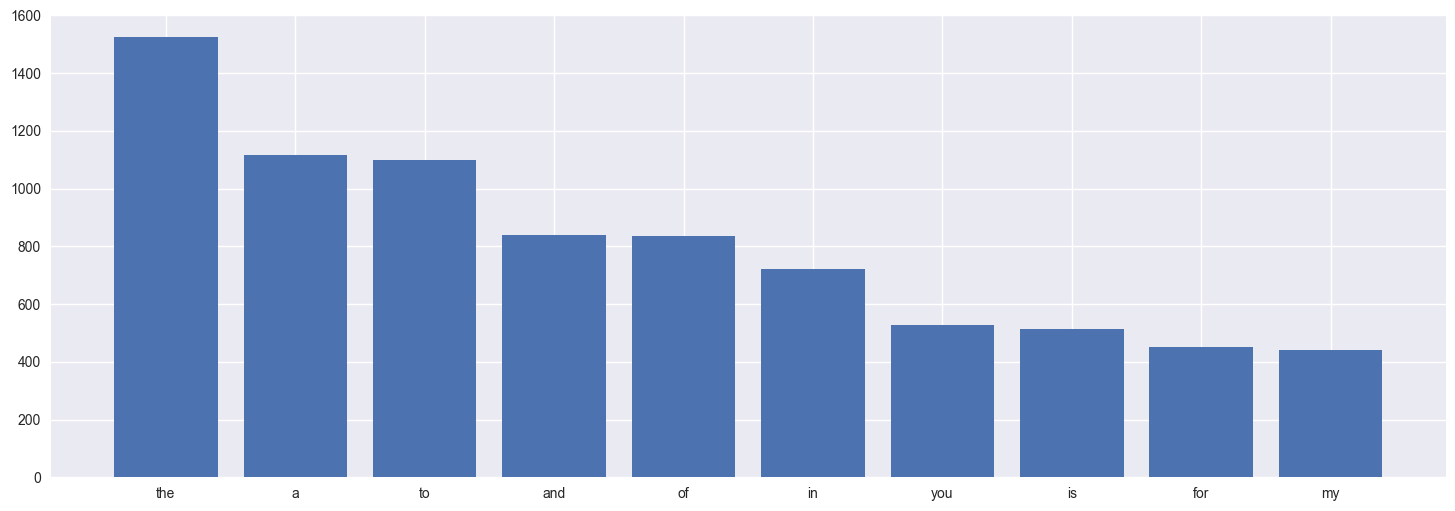

In [77]:
# Bar chart of the top 10 stopwords in non-disaster tweets
plt.rcParams['figure.figsize'] = (18.0, 6.0)
x,y=zip(*top)
plt.bar(x,y)


#### 2.5.2 Most Common Stopwords — Real Disaster Tweets (target=1)

We repeat the same analysis for real disaster tweets. Comparing both charts helps identify 
whether certain function words appear more in one class than the other.


<BarContainer object of 10 artists>

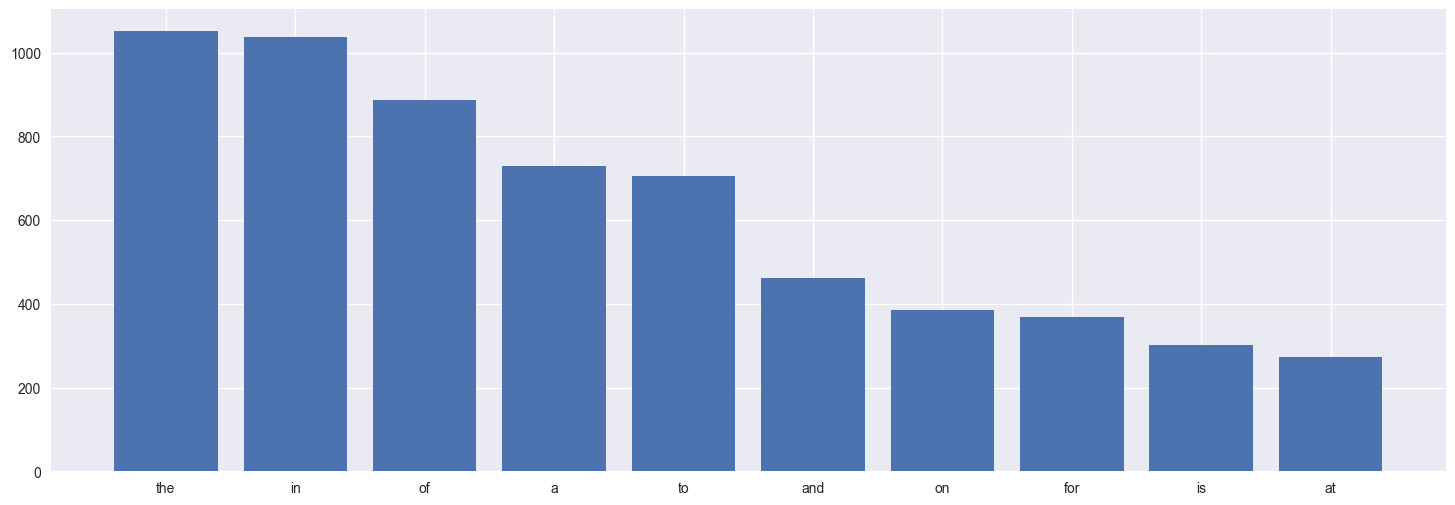

In [78]:
corpus=create_corpus(1)

dic=defaultdict(int)
for word in corpus:
    if word in stop:
        dic[word]+=1

# Sort and take top 10 stopwords for disaster tweets
top=sorted(dic.items(), key=lambda x:x[1],reverse=True)[:10] 
    

plt.rcParams['figure.figsize'] = (18.0, 6.0)
x,y=zip(*top)
plt.bar(x,y)


## 3. Text Preprocessing & Model

With the EDA done, we now move to building a neural network classifier. 
The pipeline consists of: cleaning the raw text, tokenizing, padding sequences, 
and training an Embedding + Dense model using TensorFlow/Keras.


### 3.1 Import Modeling Libraries

We use a focused set of imports specific to the modeling pipeline.


In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


### 3.2 Load Data

We reload the dataset for the modeling section.


In [80]:
df = train_tweet
df_test = test_tweet
df.head()


,id,keyword,location,text,target,length
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1,69
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1,38
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or...,1,133
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1,65
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1,88


In [81]:
# Expand column width so we can read full tweet text
pd.set_option('display.max_colwidth', 100)


In [82]:
print(df['text'])


0                                     Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
1                                                                    Forest fire near La Ronge Sask. Canada
2       All residents asked to 'shelter in place' are being notified by officers. No other evacuation or...
3                                         13,000 people receive #wildfires evacuation orders in California 
4                  Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school 
                                                       ...                                                 
7608                    Two giant cranes holding a bridge collapse into nearby homes http://t.co/STfMbbZFB5
7609    @aria_ahrary @TheTawniest The out of control wild fires in California even in the Northern part ...
7610                                      M1.94 [01:04 UTC]?5km S of Volcano Hawaii. http://t.co/zDtoyd8EbJ
7611    Police investigating

### 3.3 Text Cleaning

A quick inspection of the raw text reveals two main issues: 
URLs (e.g., `http://...`) which are meaningless to the model, and inconsistent casing. 
We define a `cleaningText` function that strips URLs using a regex and lowercases all text.


In [83]:
def cleaningText(df):
    """
    This function gets a dataframe object as an input and removes the URLs from text column and makes every sentence lowercase.
    """
    df['text'] = [re.sub(r'http\S+', '', x, flags=re.MULTILINE) for x in df['text']]
    df['text'] = df['text'].str.lower()
cleaningText(df)
df.head()


,id,keyword,location,text,target,length
0,1,NaN,NaN,our deeds are the reason of this #earthquake may allah forgive us all,1,69
1,4,NaN,NaN,forest fire near la ronge sask. canada,1,38
2,5,NaN,NaN,all residents asked to 'shelter in place' are being notified by officers. no other evacuation or...,1,133
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in california",1,65
4,7,NaN,NaN,just got sent this photo from ruby #alaska as smoke from #wildfires pours into a school,1,88


### 3.4 Prepare Sentences and Labels

We extract the cleaned tweet texts as a list of sentences and the target column as labels. 
Then we split into training and validation sets (80/20 approximate split at index 6090).


In [84]:
# Extract text and labels as plain Python lists
sentences = [x for x in df['text']]
labels = [x for x in df['target']]
print(sentences[:100])


['our deeds are the reason of this #earthquake may allah forgive us all', 'forest fire near la ronge sask. canada', "all residents asked to 'shelter in place' are being notified by officers. no other evacuation or shelter in place orders are expected", '13,000 people receive #wildfires evacuation orders in california ', 'just got sent this photo from ruby #alaska as smoke from #wildfires pours into a school ', '#rockyfire update => california hwy. 20 closed in both directions due to lake county fire - #cafire #wildfires', '#flood #disaster heavy rain causes flash flooding of streets in manitou, colorado springs areas', "i'm on top of the hill and i can see a fire in the woods...", "there's an emergency evacuation happening now in the building across the street", "i'm afraid that the tornado is coming to our area...", 'three people died from the heat wave so far', 'haha south tampa is getting flooded hah- wait a second i live in south tampa what am i gonna do what am i gonna do fvck #fl

In [85]:
# Manual train/test split at index 6090
labels = np.array(labels)
training_sentences = sentences[:6090]
training_labels = labels[:6090]
testing_sentences = sentences[6090:]
testing_labels = labels[6090:]


### 3.5 Tokenization Hyperparameters

Before tokenizing, we define the key hyperparameters:

- **`vocab_size = 10000`**: Maximum number of unique words stored in the vocabulary dictionary.
- **`embedding_dim = 16`**: Dimensionality of the word embedding space — each word maps to a 16-dimensional dense vector.
- **`max_length = 280`**: Since tweets can be up to 280 characters, we set the sequence length accordingly.
- **`trunc_type = 'post'`**: Sequences longer than `max_length` are truncated from the end.
- **`oov_tok = '<OOV>'`**: Token used for out-of-vocabulary words seen at inference time.

All words in the training sentences are mapped to integer indices. 
Sequences are padded or truncated so every input has the same shape, which is required by the model.


In [86]:
vocab_size = 10000
embedding_dim = 16
max_length = 280
trunc_type='post'
oov_tok = "<OOV>"

# Fit tokenizer on training text and convert to padded integer sequences
tokenizer = Tokenizer(num_words = vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(training_sentences)
word_index = tokenizer.word_index
sequences = tokenizer.texts_to_sequences(training_sentences)
padded = pad_sequences(sequences,maxlen=max_length, truncating=trunc_type)

# Apply the same tokenizer (no re-fitting) to test sentences
testing_sequences = tokenizer.texts_to_sequences(testing_sentences)
testing_padded = pad_sequences(testing_sequences,maxlen=max_length)


### 3.6 Model Architecture

We use a simple but effective sequential architecture:

1. **Embedding layer** — learns a dense vector representation for each word in the vocabulary.
2. **GlobalAveragePooling1D** — averages the embeddings across all positions in the sequence, 
   producing a fixed-size representation regardless of tweet length.
3. **Dense(6, relu)** — a small hidden layer to learn non-linear combinations of features.
4. **Dense(1, sigmoid)** — output layer producing a probability between 0 and 1 (disaster or not).

We compile with **binary crossentropy** loss (standard for binary classification) and the **Adam** optimizer.


In [87]:
# Build the sequential model
model = tf.keras.Sequential([
tf.keras.layers.Embedding(vocab_size,embedding_dim,input_length = max_length),
tf.keras.layers.GlobalAveragePooling1D(),
tf.keras.layers.Dense(6, activation = "relu"),
tf.keras.layers.Dense(1, activation = "sigmoid")
])
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 3.7 Training

We train for **10 epochs** with a fixed random seed for reproducibility. 
Validation accuracy is monitored at each epoch using the held-out testing set.


In [88]:
np.random.seed(42)  # Set seed for reproducibility
num_epochs = 10
model.fit( padded, training_labels,epochs = num_epochs, validation_data = (testing_padded, testing_labels))


Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5780 - loss: 0.6813 - val_accuracy: 0.5345 - val_loss: 0.6912
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5793 - loss: 0.6803 - val_accuracy: 0.5345 - val_loss: 0.6938
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5793 - loss: 0.6795 - val_accuracy: 0.5345 - val_loss: 0.6939
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5793 - loss: 0.6778 - val_accuracy: 0.5345 - val_loss: 0.6911
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5793 - loss: 0.6769 - val_accuracy: 0.5345 - val_loss: 0.6880
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5793 - loss: 0.6741 - val_accuracy: 0.5345 - val_loss: 0.6908
Epoch 7/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5793 - loss: 0.6714 - val_accuracy: 0.5345 - val_loss: 0.6882
Epoch 8/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5793 - loss: 0.6697 - val_accuracy: 0.